# 03. 서울 빈집 현황 및 임대차 시장 분석 (2023–2025)

**목표:** 서울 25개 자치구의 실제 빈집 수를 연도·주택유형별로 분석하고, 임대차 거래량·인구이동·생활인구·기준금리와의 관계를 탐색합니다.

> `total`은 실제 빈집 수(호)이며, 임대차 `contractCount`와는 서로 다른 지표입니다. 상관관계는 인과관계를 의미하지 않습니다.


## 1. 빈집 원본 데이터 로드

서울통계에서 확보한 2023~2025년 자치구별 빈집 CSV를 불러오고 인코딩을 확인합니다.


In [1]:
import pandas as pd

path = "../data/raw/vacancy_seoul_2023_2025.csv"

for encoding in ["utf-8", "cp949", "euc-kr"]:
    try:
        vacancy_raw = pd.read_csv(path, encoding=encoding)
        print("encoding:", encoding)
        print("shape:", vacancy_raw.shape)
        print(vacancy_raw.columns.tolist())
        display(vacancy_raw.head())
        break
    except UnicodeDecodeError:
        continue

encoding: utf-8
shape: (28, 19)
['자치구별(1)', '2023', '2023.1', '2023.2', '2023.3', '2023.4', '2023.5', '2024', '2024.1', '2024.2', '2024.3', '2024.4', '2024.5', '2025', '2025.1', '2025.2', '2025.3', '2025.4', '2025.5']


,자치구별(1),2023,2023.1,2023.2,2023.3,2023.4,2023.5,2024,2024.1,2024.2,2024.3,2024.4,2024.5,2025,2025.1,2025.2,2025.3,2025.4,2025.5
0,자치구별(1),계,계,계,계,계,계,계,계,계,계,계,계,계,계,계,계,계,계
1,자치구별(1),소계,단독주택,아파트,연립주택,다세대주택,비주거용 건물내 주택,소계,단독주택,아파트,연립주택,다세대주택,비주거용 건물내 주택,소계,단독주택,아파트,연립주택,다세대주택,비주거용 건물내 주택
2,계,107681,4270,55087,6537,40183,1604,102556,4603,50820,5890,39546,1697,126290,6826,63008,7087,47287,2082
3,종로구,2144,243,703,305,775,118,2123,298,643,308,760,114,2416,338,784,318,861,115
4,중구,1752,49,1390,38,179,96,1766,58,1334,37,216,121,2817,332,1905,95,340,145


## 2. 빈집 데이터 정제

서울 전체 합계 행과 메타데이터 행을 제외하고 25개 자치구 × 3개 연도의 분석 테이블을 생성합니다.


In [2]:
types = [
    "total",
    "detached",
    "apartment",
    "rowHouse",
    "multiFamily",
    "nonResidential"
]

rows = []

# 서울 전체 '계' 행은 제외하고 자치구만 사용
for _, row in vacancy_raw.iloc[3:].iterrows():
    gu = row["자치구별(1)"]

    for year in [2023, 2024, 2025]:
        start = 1 + (year - 2023) * 6

        data = {
            "guName": gu,
            "year": year
        }

        for i, housing_type in enumerate(types):
            data[housing_type] = row.iloc[start + i]

        rows.append(data)

vacancy = pd.DataFrame(rows)

for col in types:
    vacancy[col] = pd.to_numeric(vacancy[col], errors="coerce")

print("shape:", vacancy.shape)
print("자치구 수:", vacancy["guName"].nunique())
print("기간:", vacancy["year"].min(), "~", vacancy["year"].max())
print("결측치:")
print(vacancy.isnull().sum())

display(vacancy.head(10))

shape: (75, 8)
자치구 수: 25
기간: 2023 ~ 2025
결측치:
guName            0
year              0
total             0
detached          0
apartment         0
rowHouse          0
multiFamily       0
nonResidential    0
dtype: int64


,guName,year,total,detached,apartment,rowHouse,multiFamily,nonResidential
0,종로구,2023,2144,243,703,305,775,118
1,종로구,2024,2123,298,643,308,760,114
2,종로구,2025,2416,338,784,318,861,115
3,중구,2023,1752,49,1390,38,179,96
4,중구,2024,1766,58,1334,37,216,121
5,중구,2025,2817,332,1905,95,340,145
6,용산구,2023,5059,324,2708,431,1495,101
7,용산구,2024,7499,1553,2936,617,2281,112
8,용산구,2025,7846,1884,3147,630,2049,136
9,성동구,2023,2030,20,1414,90,439,67


## 3. 연도별 서울 빈집 현황


In [3]:
yearly_vacancy = (
    vacancy.groupby("year")["total"]
    .sum()
    .reset_index()
)

display(yearly_vacancy)

,year,total
0,2023,107681
1,2024,102556
2,2025,126290


### 3-1. 2025년 자치구별 빈집 현황


In [4]:
vacancy_2025 = (
    vacancy[vacancy["year"] == 2025]
    .sort_values("total", ascending=False)
)

display(
    vacancy_2025[
        ["guName", "total", "detached", "apartment",
         "rowHouse", "multiFamily", "nonResidential"]
    ]
)

,guName,total,detached,apartment,rowHouse,multiFamily,nonResidential
47,강서구,12124,293,5215,371,6144,101
68,강남구,10976,12,5369,555,4944,96
32,노원구,8963,67,7615,193,1049,39
8,용산구,7846,1884,3147,630,2049,136
35,은평구,7044,370,2096,461,4014,103
50,구로구,6575,52,3163,737,2570,53
71,송파구,6348,244,2903,249,2850,102
74,강동구,5825,9,3846,151,1766,53
65,서초구,5776,25,3797,314,1531,109
44,양천구,5593,33,2561,228,2705,66


## 4. 임대차 시장 데이터 결합

MySQL `ml_rent_market`을 불러와 연간 단위로 집계한 뒤 빈집 데이터와 결합합니다.


In [5]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env", override=True)

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

market = pd.read_sql(
    "SELECT * FROM ml_rent_market",
    engine
)

print("shape:", market.shape)
display(market.head())

shape: (900, 8)


,guName,yearMonth,contractCount,moveIn,moveOut,netMove,baseRate,avgLivingPop
0,강남구,2023-01,2171,6159,6350,-191,3.5,796674.223998
1,강남구,2023-02,2825,9166,8126,1040,3.5,831518.858496
2,강남구,2023-03,3016,11083,8257,2826,3.5,823731.966718
3,강남구,2023-04,2354,7931,6102,1829,3.5,809914.335772
4,강남구,2023-05,2291,7696,6657,1039,3.5,807608.549482


In [6]:
market["year"] = market["yearMonth"].str[:4].astype(int)

annual_market = (
    market.groupby(["guName", "year"])
    .agg(
        contractCount=("contractCount", "sum"),
        moveIn=("moveIn", "sum"),
        moveOut=("moveOut", "sum"),
        netMove=("netMove", "sum"),
        avgLivingPop=("avgLivingPop", "mean"),
        avgBaseRate=("baseRate", "mean")
    )
    .reset_index()
)

vacancy_market = vacancy.merge(
    annual_market,
    on=["guName", "year"],
    how="left"
)

print("shape:", vacancy_market.shape)
print("결측치:")
print(vacancy_market.isnull().sum())

shape: (75, 14)
결측치:
guName            0
year              0
total             0
detached          0
apartment         0
rowHouse          0
multiFamily       0
nonResidential    0
contractCount     0
moveIn            0
moveOut           0
netMove           0
avgLivingPop      0
avgBaseRate       0
dtype: int64


## 5. 빈집 수와 시장 변수의 관계

빈집 수와 연간 거래량·인구이동·생활인구·기준금리의 상관관계를 확인합니다.

> 자치구 규모가 큰 지역은 주택 수·생활인구·거래량·빈집 수가 함께 커질 수 있으므로 단순 상관계수를 인과효과로 해석하지 않습니다.


In [7]:
corr = vacancy_market[
    ["total", "contractCount", "moveIn", "moveOut",
     "netMove", "avgLivingPop", "avgBaseRate"]
].corr()

print(corr["total"].sort_values(ascending=False))

total            1.000000
contractCount    0.685826
avgLivingPop     0.592323
moveOut          0.444752
moveIn           0.439616
netMove          0.090419
avgBaseRate     -0.143101
Name: total, dtype: float64


## 6. 자치구별 빈집 증감

전년 대비 빈집 수와 증감률을 계산합니다.


In [8]:
vacancy_market = vacancy_market.sort_values(["guName", "year"])

vacancy_market["vacancyChange"] = (
    vacancy_market.groupby("guName")["total"].diff()
)

vacancy_market["vacancyChangeRate"] = (
    vacancy_market.groupby("guName")["total"].pct_change() * 100
)

display(
    vacancy_market[vacancy_market["year"] == 2025]
    [["guName", "total", "vacancyChange", "vacancyChangeRate"]]
    .sort_values("vacancyChange", ascending=False)
)

,guName,total,vacancyChange,vacancyChangeRate
17,동대문구,5041,2672.0,112.790207
32,노원구,8963,2027.0,29.224337
35,은평구,7044,1756.0,33.207262
38,서대문구,4124,1678.0,68.601799
47,강서구,12124,1648.0,15.731195
26,강북구,5365,1488.0,38.380191
20,중랑구,3586,1378.0,62.409420
71,송파구,6348,1161.0,22.382880
5,중구,2817,1051.0,59.513024
23,성북구,4593,1036.0,29.125668


### 6-1. 2024 → 2025 자치구별 빈집 증감 시각화


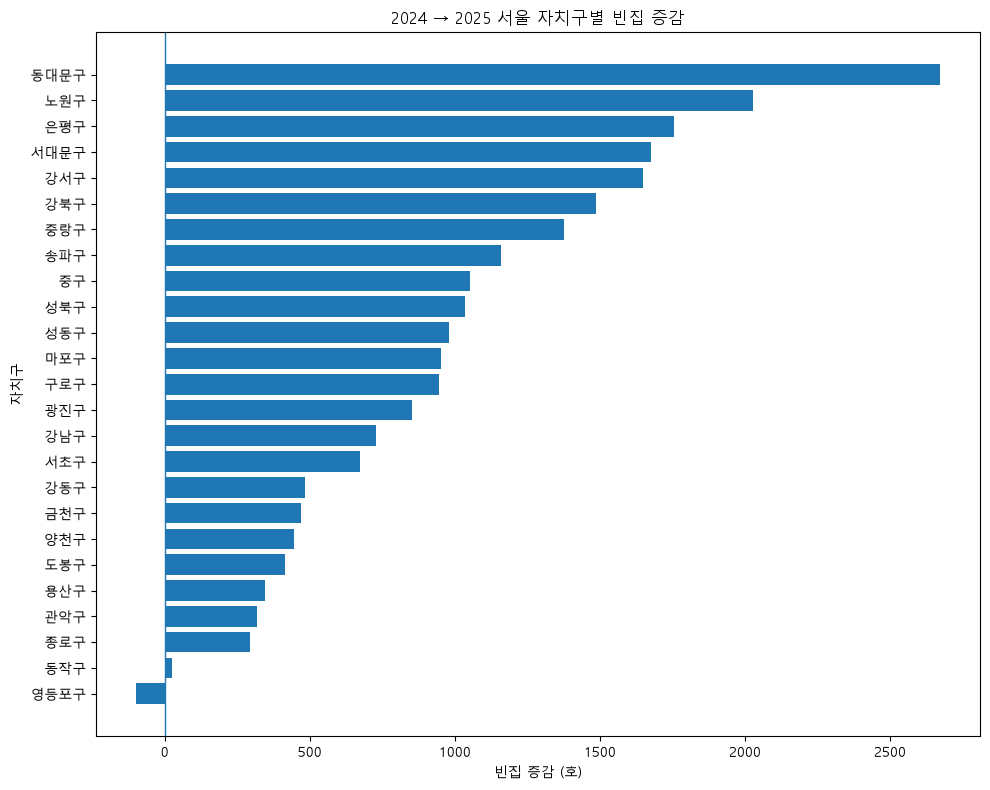

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

change_2025 = (
    vacancy_market[vacancy_market["year"] == 2025]
    .sort_values("vacancyChange")
)

plt.figure(figsize=(10, 8))
plt.barh(change_2025["guName"], change_2025["vacancyChange"])
plt.title("2024 → 2025 서울 자치구별 빈집 증감")
plt.xlabel("빈집 증감 (호)")
plt.ylabel("자치구")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


## 7. 주택유형별 빈집 구성

단독주택·아파트·연립주택·다세대주택·비주거용 건물 내 주택의 연도별 구성 변화를 확인합니다.


In [10]:
housing_types = [
    "detached",
    "apartment",
    "rowHouse",
    "multiFamily",
    "nonResidential"
]

type_summary = (
    vacancy.groupby("year")[housing_types]
    .sum()
)

display(type_summary)

,detached,apartment,rowHouse,multiFamily,nonResidential
year,,,,,
2023,4270,55087,6537,40183,1604
2024,4603,50820,5890,39546,1697
2025,6826,63008,7087,47287,2082


In [11]:
type_ratio = type_summary.div(type_summary.sum(axis=1), axis=0) * 100

display(type_ratio.round(2))

,detached,apartment,rowHouse,multiFamily,nonResidential
year,,,,,
2023,3.97,51.16,6.07,37.32,1.49
2024,4.49,49.55,5.74,38.56,1.65
2025,5.41,49.89,5.61,37.44,1.65


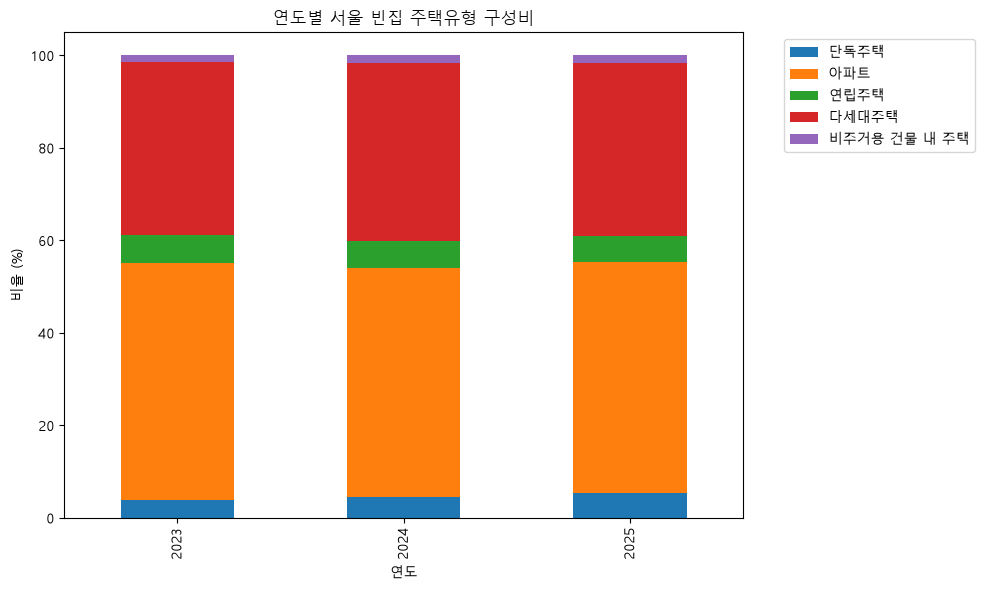

In [12]:
type_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("연도별 서울 빈집 주택유형 구성비")
plt.xlabel("연도")
plt.ylabel("비율 (%)")
plt.legend(
    ["단독주택", "아파트", "연립주택", "다세대주택", "비주거용 건물 내 주택"],
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

## 8. 빈집 수와 임대차 거래량 비교


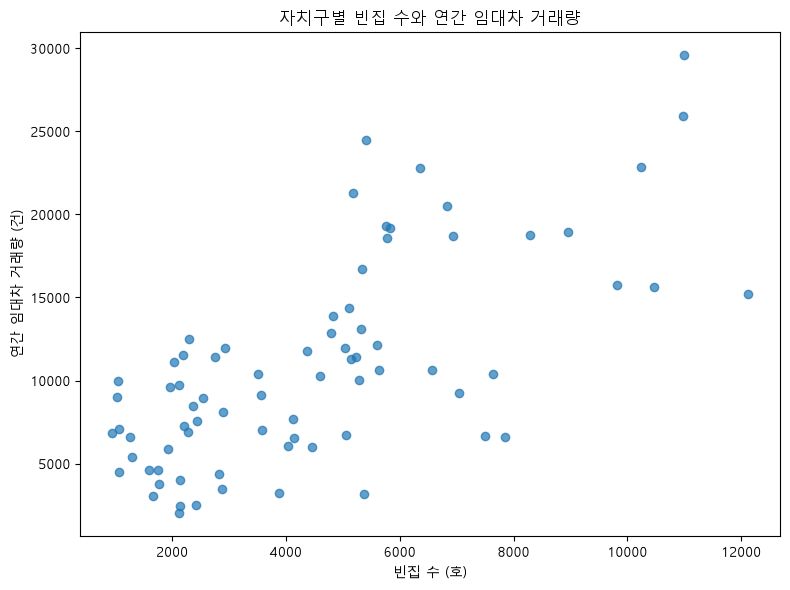

상관계수: 0.6858259032096004


In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    vacancy_market["total"],
    vacancy_market["contractCount"],
    alpha=0.7
)

plt.title("자치구별 빈집 수와 연간 임대차 거래량")
plt.xlabel("빈집 수 (호)")
plt.ylabel("연간 임대차 거래량 (건)")

plt.tight_layout()
plt.show()

print(
    "상관계수:",
    vacancy_market["total"].corr(vacancy_market["contractCount"])
)

## 9. 분석 결과 MySQL 저장

대시보드에서 재사용할 수 있도록 최종 연간 분석 테이블을 `vacancy_market_analysis`에 저장합니다.


In [14]:
vacancy_market.to_sql(
    "vacancy_market_analysis",
    engine,
    if_exists="replace",
    index=False
)

print("MySQL 저장 완료:", len(vacancy_market))

MySQL 저장 완료: 75


## 10. 해석 시 주의사항

- 빈집 수는 실제 미거주 주택 수이며 전월세 거래량과 동일한 개념이 아닙니다.
- 현재 데이터는 빈집 **수**이므로 자치구 간 공정한 비교를 위해서는 향후 전체 주택 수를 확보해 빈집률을 계산하는 것이 좋습니다.
- 빈집 수와 거래량·생활인구 등의 상관관계는 지역 규모의 영향을 받을 수 있습니다.
- 연간 빈집 통계는 월별 예측 모델에 그대로 투입하지 않고 별도의 설명·비교 분석에 사용합니다.
